In [800]:
#FOR EDA
import pandas as pd
import numpy as np

#FOR VISUALS
import matplotlib.pyplot as plt
import seaborn as sns

#FOR DATA PREPROCESSING
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

#CLASSIFIER LIBRARIES
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# !pip install xgboost
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# EVALUATION METRICS
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [801]:
heart_data = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\Downloads\heart - heart ML.csv")

In [802]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# Features used in This dataset For heart disease prediction tasks.

#### age: Age in years.
#### sex: Gender (1 = male; 0 = female).
#### cp: Chest pain type (1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic).
#### trestbps: Resting blood pressure (in mm Hg on admission to the hospital).
#### chol: Serum cholesterol in mg/dl.
#### fbs: Fasting blood sugar > 120 mg/dl (1 = true; 0 = false).
#### restecg: Resting electrocardiographic results.
#### thalach: Maximum heart rate achieved.
#### exang: Exercise-induced angina (1 = yes; 0 = no).
#### oldpeak: ST depression induced by exercise relative to rest.
#### slope: The slope of the peak exercise ST segment.
#### ca: Number of major vessels (0–3) colored by fluoroscopy.
#### thal: 3 = normal; 6 = fixed defect; 7 = reversible defect.
#### target: Presence of heart disease (1 = yes; 0 = no).

In [804]:
heart_data.columns = ['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholesterol', 'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression', 'st_slope', 'number_of_major_vessel', 'thalassemia', 'target']

In [805]:
heart_data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,number_of_major_vessel,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [806]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      303 non-null    int64  
 1   sex                      303 non-null    int64  
 2   chest_pain_type          303 non-null    int64  
 3   resting_blood_pressure   303 non-null    int64  
 4   cholesterol              303 non-null    int64  
 5   fasting_blood_sugar      303 non-null    int64  
 6   rest_ecg                 303 non-null    int64  
 7   max_heart_rate_achieved  303 non-null    int64  
 8   exercise_induced_angina  303 non-null    int64  
 9   st_depression            303 non-null    float64
 10  st_slope                 303 non-null    int64  
 11  number_of_major_vessel   303 non-null    int64  
 12  thalassemia              303 non-null    int64  
 13  target                   303 non-null    int64  
dtypes: float64(1), int64(13)
m

In [807]:
heart_data.shape

(303, 14)

In [808]:
heart_data.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholesterol', 'fasting_blood_sugar', 'rest_ecg',
       'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression',
       'st_slope', 'number_of_major_vessel', 'thalassemia', 'target'],
      dtype='object')

In [809]:
heart_data.describe()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,number_of_major_vessel,thalassemia,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [810]:
heart_data.isnull().sum()

age                        0
sex                        0
chest_pain_type            0
resting_blood_pressure     0
cholesterol                0
fasting_blood_sugar        0
rest_ecg                   0
max_heart_rate_achieved    0
exercise_induced_angina    0
st_depression              0
st_slope                   0
number_of_major_vessel     0
thalassemia                0
target                     0
dtype: int64

<Axes: >

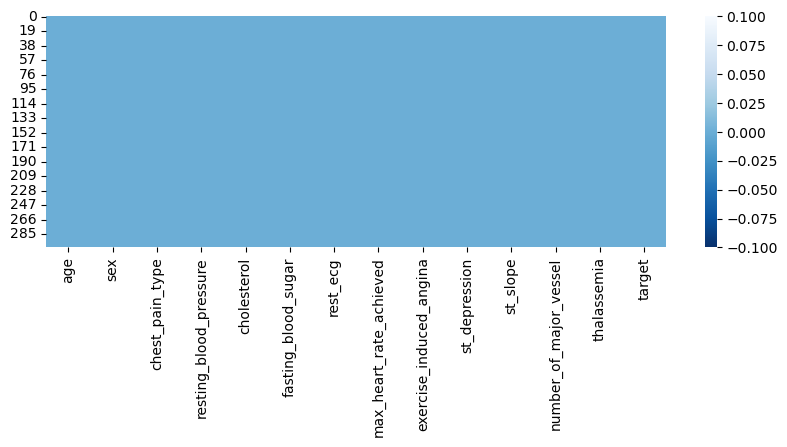

In [811]:
heart_data.isnull().sum()
plt.figure(figsize=(10,3))
sns.heatmap(heart_data.isnull(), cbar=True, cmap="Blues_r")

In [812]:
heart_data.dtypes

age                          int64
sex                          int64
chest_pain_type              int64
resting_blood_pressure       int64
cholesterol                  int64
fasting_blood_sugar          int64
rest_ecg                     int64
max_heart_rate_achieved      int64
exercise_induced_angina      int64
st_depression              float64
st_slope                     int64
number_of_major_vessel       int64
thalassemia                  int64
target                       int64
dtype: object

## EXPLANATORY DATA ANALYSIS

## UNIVARIATE ANALYSIS

In [815]:
heart_data.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholesterol', 'fasting_blood_sugar', 'rest_ecg',
       'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression',
       'st_slope', 'number_of_major_vessel', 'thalassemia', 'target'],
      dtype='object')

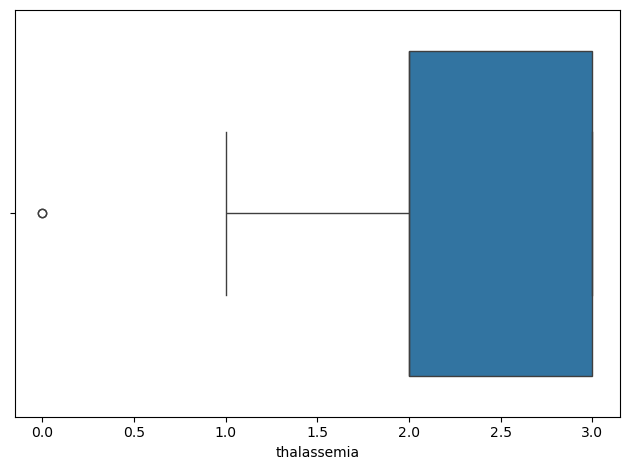

In [816]:
sns.boxplot(x=heart_data["thalassemia"])

plt.tight_layout()
plt.show()

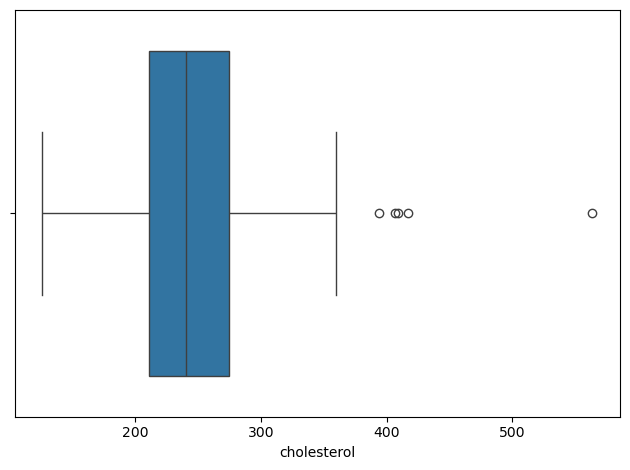

In [817]:
sns.boxplot(x=heart_data["cholesterol"])

plt.tight_layout()
plt.show()

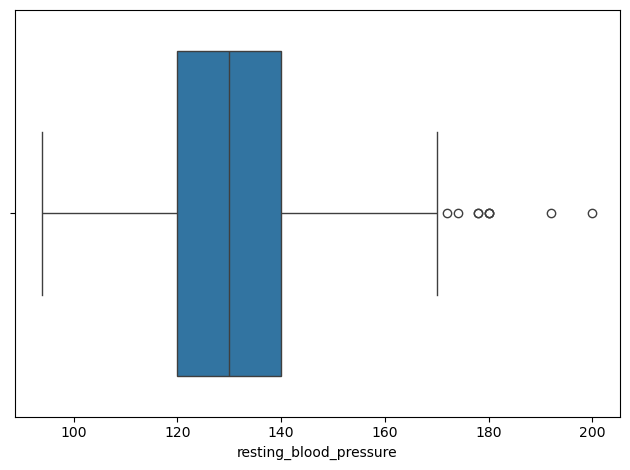

In [818]:
sns.boxplot(x=heart_data["resting_blood_pressure"])

plt.tight_layout()
plt.show()

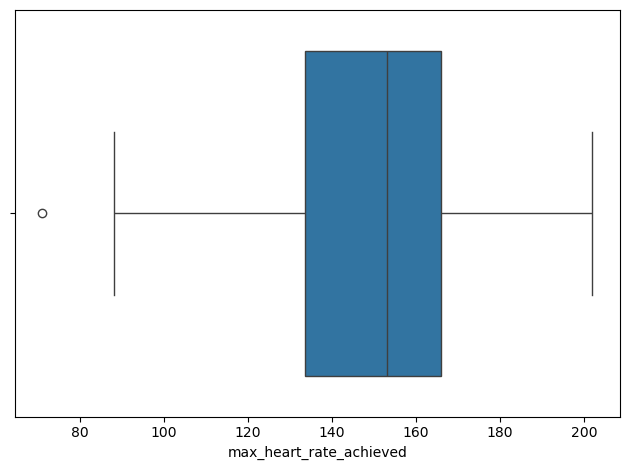

In [819]:
sns.boxplot(x=heart_data["max_heart_rate_achieved"])

plt.tight_layout()
plt.show()

In [820]:
# Define the age_group function
def age_bracket(x):
    if x <= 35:
        return "youth(<=35)"
    elif x <= 55:
        return "Adult(<=55)"
    elif x <= 65:
        return "Old Adult(<=65)"
    else:
        return "Elder(>65)"

heart_data["age_bracket"] = heart_data["age"].apply(age_bracket)
heart_data.head(2)   

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,number_of_major_vessel,thalassemia,target,age_bracket
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,Old Adult(<=65)
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,Adult(<=55)


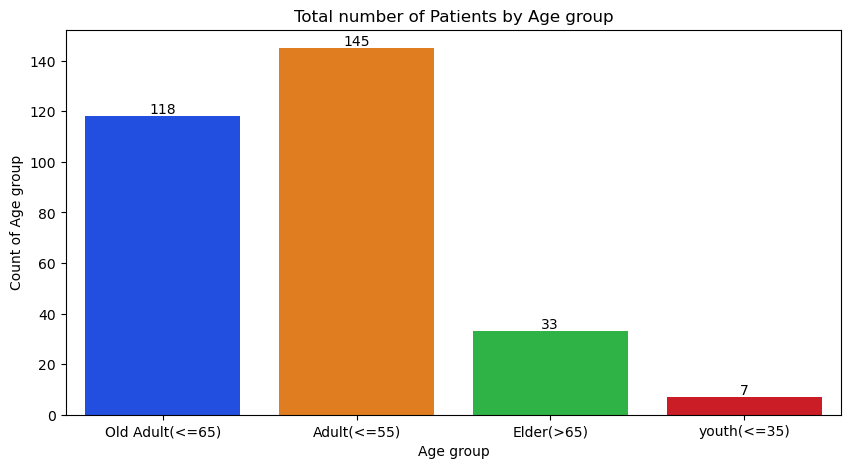

In [821]:
plt.figure(figsize=(10,5))
ax=sns.countplot(x="age_bracket", palette='bright', data=heart_data)
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
plt.xlabel('Age group')
plt.ylabel('Count of Age group')
plt.title('Total number of Patients by Age group');

In [822]:
def gender (sex):
    if sex == 1:
        return "Male"
    else:
        return "Female"
heart_data["gender"] = heart_data["sex"].apply(gender)
heart_data.head(2)        

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,number_of_major_vessel,thalassemia,target,age_bracket,gender
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,Old Adult(<=65),Male
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,Adult(<=55),Male


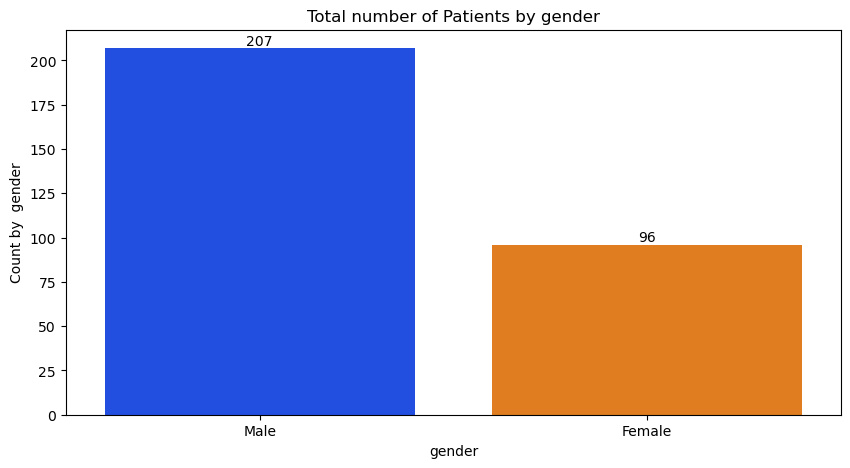

In [823]:
plt.figure(figsize=(10,5))
ax=sns.countplot(x="gender", palette='bright', data=heart_data)
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
plt.xlabel('gender')
plt.ylabel('Count by  gender')
plt.title('Total number of Patients by gender');

In [824]:
# chest_pain_type (0:asymptomatic, 1: typical angina, 2: atypical angina, 3: non anginal pain)
def chest_pain(cp):
    if cp == 1:
        return "typical angina"
    elif cp == 2:
        return "atypical angina"
    elif cp == 3:
        return "non anginal pain"
    else:
        return "asymptomatic"

heart_data["chest_pain"] = heart_data["chest_pain_type"].apply(chest_pain)
heart_data.head(2)   

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,number_of_major_vessel,thalassemia,target,age_bracket,gender,chest_pain
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,Old Adult(<=65),Male,non anginal pain
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,Adult(<=55),Male,atypical angina


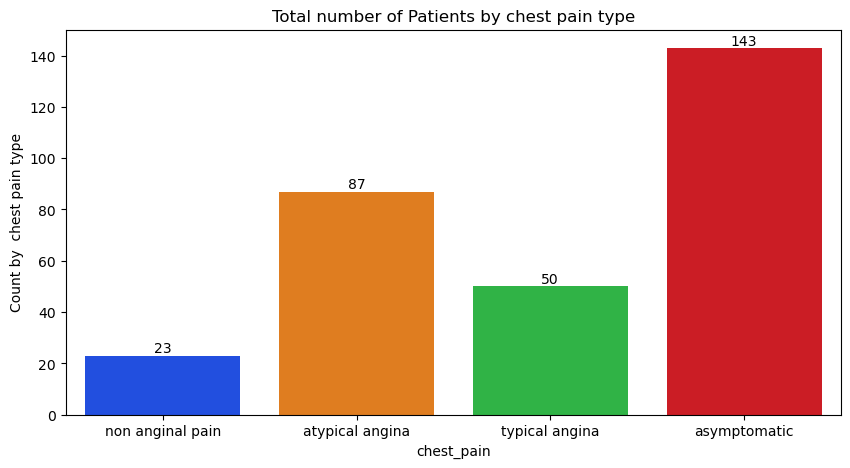

In [825]:
plt.figure(figsize=(10,5))
ax=sns.countplot(x="chest_pain", palette='bright', data=heart_data)
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
plt.xlabel('chest_pain')
plt.ylabel('Count by  chest pain type')
plt.title('Total number of Patients by chest pain type');

In [826]:
def label (target):
    if target == 1:
        return "yes"
    else:
        return "no"
heart_data["label"] = heart_data["target"].apply(label)
heart_data.head(2)  

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,number_of_major_vessel,thalassemia,target,age_bracket,gender,chest_pain,label
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,Old Adult(<=65),Male,non anginal pain,yes
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,Adult(<=55),Male,atypical angina,yes


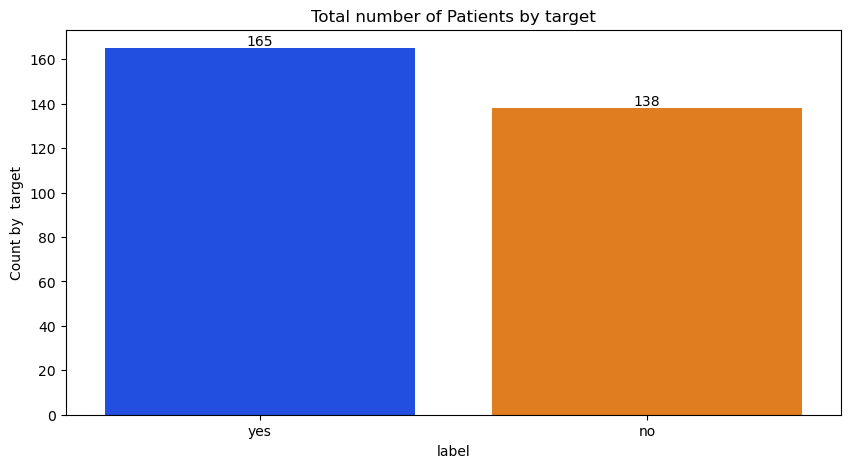

In [827]:
plt.figure(figsize=(10,5))
ax=sns.countplot(x="label", palette='bright', data=heart_data)
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
plt.xlabel('label')
plt.ylabel('Count by  target')
plt.title('Total number of Patients by target');

## BIVARIATE ANALYSIS

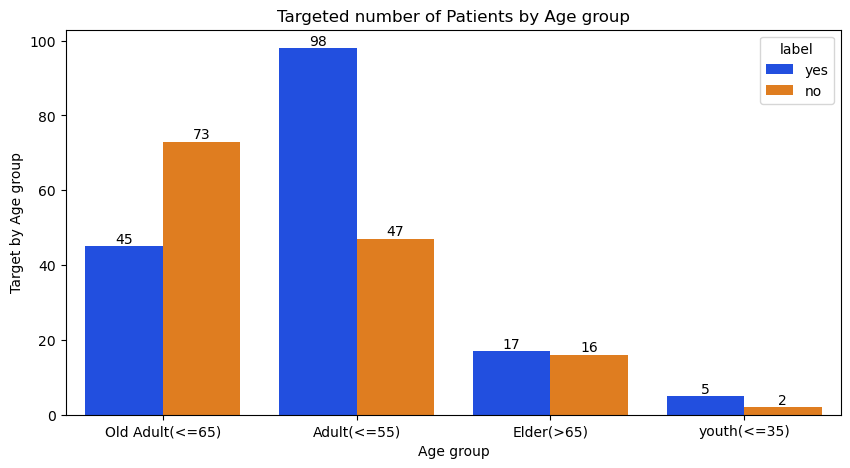

In [829]:
plt.figure(figsize=(10,5))
ax=sns.countplot(x="age_bracket", palette='bright', hue='label', data=heart_data)
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
plt.xlabel('Age group')
plt.ylabel('Target by Age group')
plt.title('Targeted number of Patients by Age group');

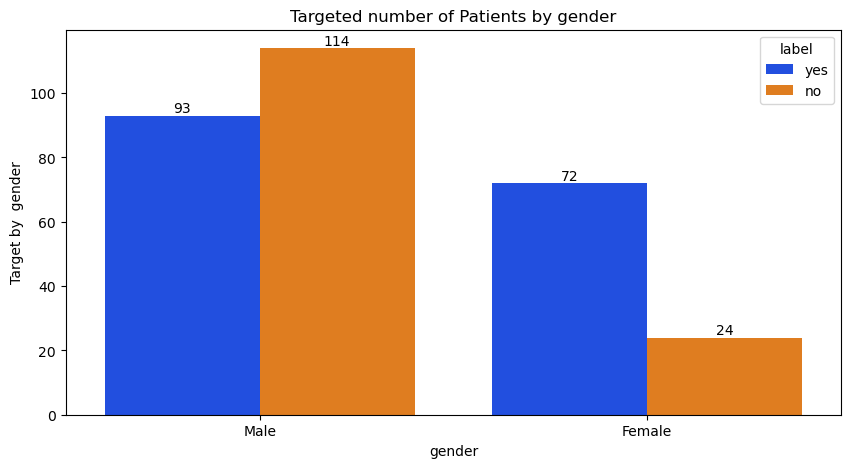

In [830]:
plt.figure(figsize=(10,5))
ax=sns.countplot(x="gender", palette='bright',hue='label',data=heart_data)
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
plt.xlabel('gender')
plt.ylabel('Target by  gender')
plt.title('Targeted number of Patients by gender');

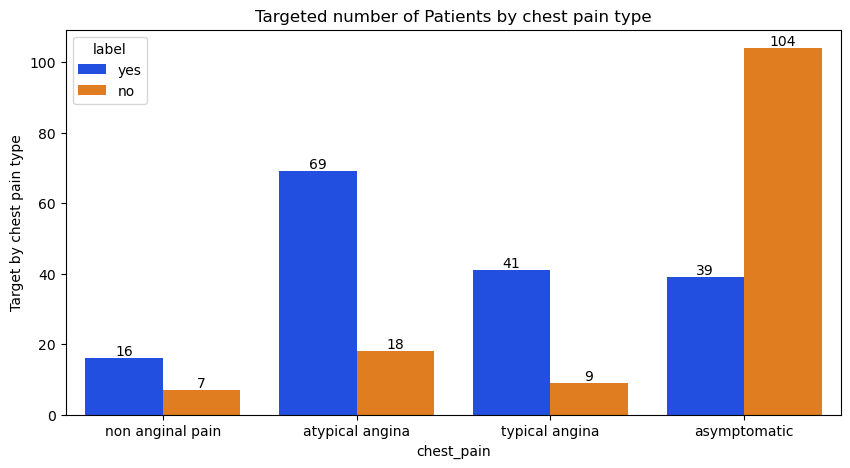

In [831]:
plt.figure(figsize=(10,5))
ax=sns.countplot(x='chest_pain', palette='bright',hue='label', data=heart_data)
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
plt.xlabel('chest_pain')
plt.ylabel('Target by chest pain type')
plt.title('Targeted number of Patients by chest pain type');

## MULTIVARIATE ANALYSIS

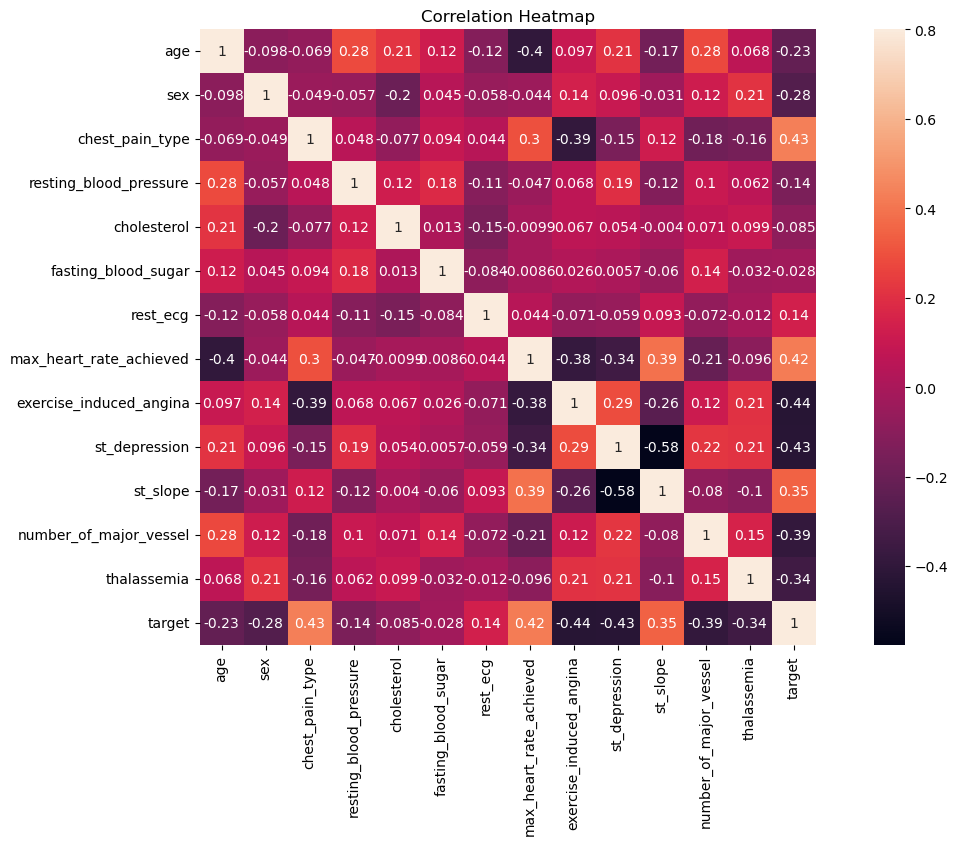

In [833]:
heart_data = heart_data.select_dtypes(include=[float, int])
a = heart_data.corr()
plt.figure(figsize=(15, 8))
sns.heatmap(a, vmax=0.8, square=True, annot=True)
plt.title("Correlation Heatmap")
plt.show()

### FEATURE ENGINEERING/ DATA PREPROCESSING

In [835]:
heart_data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,number_of_major_vessel,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [836]:
df= heart_data[['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholesterol', 'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate_achieved', 
            'exercise_induced_angina', 'st_depression', 'st_slope', 'number_of_major_vessel', 'thalassemia']]
label=heart_data[['target']]

In [837]:
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,number_of_major_vessel,thalassemia
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [838]:
label.head()

,target
0,1
1,1
2,1
3,1
4,1


In [839]:
df.dtypes

age                          int64
sex                          int64
chest_pain_type              int64
resting_blood_pressure       int64
cholesterol                  int64
fasting_blood_sugar          int64
rest_ecg                     int64
max_heart_rate_achieved      int64
exercise_induced_angina      int64
st_depression              float64
st_slope                     int64
number_of_major_vessel       int64
thalassemia                  int64
dtype: object

In [840]:
# Handling outliers- [thalassemia, cholesterol, resting blood sugar and max heart rateachieved]
handler = MinMaxScaler()
df['handled_thalassemia']= handler.fit_transform(df['thalassemia'].values.reshape(-1,1))
df['handled_cholesterol']= handler.fit_transform(df['cholesterol'].values.reshape(-1,1))
df['handled_resting_blood_pressure']= handler.fit_transform(df['resting_blood_pressure'].values.reshape(-1,1))
df['handled_max_heart_rate_achieved']= handler.fit_transform(df['max_heart_rate_achieved'].values.reshape(-1,1))

In [841]:
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,number_of_major_vessel,thalassemia,handled_thalassemia,handled_cholesterol,handled_resting_blood_pressure,handled_max_heart_rate_achieved
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,0.333333,0.244292,0.481132,0.603053
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,0.666667,0.283105,0.339623,0.885496
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,0.666667,0.178082,0.339623,0.770992
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,0.666667,0.251142,0.245283,0.816794
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,0.666667,0.520548,0.245283,0.702290


In [842]:
df.drop(['thalassemia', 'cholesterol', 'resting_blood_pressure', 'max_heart_rate_achieved'], axis= 1, inplace= True)

In [843]:
df.head()

,age,sex,chest_pain_type,fasting_blood_sugar,rest_ecg,exercise_induced_angina,st_depression,st_slope,number_of_major_vessel,handled_thalassemia,handled_cholesterol,handled_resting_blood_pressure,handled_max_heart_rate_achieved
0,63,1,3,1,0,0,2.3,0,0,0.333333,0.244292,0.481132,0.603053
1,37,1,2,0,1,0,3.5,0,0,0.666667,0.283105,0.339623,0.885496
2,41,0,1,0,0,0,1.4,2,0,0.666667,0.178082,0.339623,0.770992
3,56,1,1,0,1,0,0.8,2,0,0.666667,0.251142,0.245283,0.816794
4,57,0,0,0,1,1,0.6,2,0,0.666667,0.520548,0.245283,0.702290


### MACHINE LEARNING

In [845]:
# SPLIT Trainig and Testing
X_train, X_test, y_train, y_test = train_test_split(df, label, test_size= 0.2, random_state= 42)

In [846]:
# MODEL BUILDING
# LOGISTIC REGRESSION

logreg = LogisticRegression()

logreg.fit(X_train, y_train)
ly_pred = logreg.predict(X_test)

print("Logistic Regression")
print('Acuuracy:', accuracy_score(y_test, ly_pred))
print('Precision:', precision_score(y_test, ly_pred))
print('Recall:', recall_score(y_test, ly_pred))
print('F1_score:', f1_score(y_test, ly_pred))
print('AUC_ROC:', roc_auc_score(y_test, ly_pred))

Logistic Regression
Acuuracy: 0.8524590163934426
Precision: 0.8709677419354839
Recall: 0.84375
F1_score: 0.8571428571428571
AUC_ROC: 0.8529094827586207


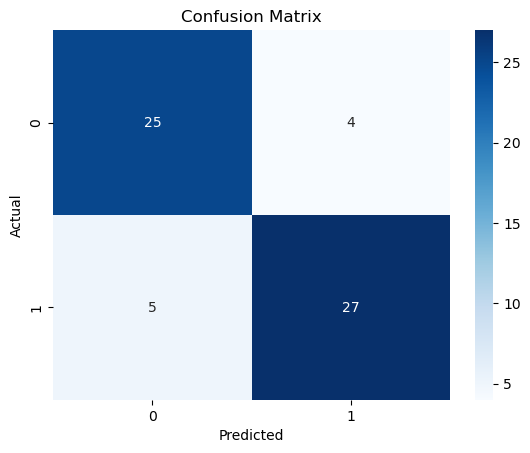

In [847]:
# COFUSION MATRIX
LCM = confusion_matrix(y_test, ly_pred)
# HEATMAP
sns.heatmap(LCM, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [848]:
# MODEL BUILDING
# LOGISTIC REGRESSION

rfc = RandomForestClassifier()

rfc.fit(X_train, y_train)
rfc_pred = rfc.predict(X_test)

print("Logistic Regression")
print('Acuuracy:', accuracy_score(y_test, rfc_pred))
print('Precision:', precision_score(y_test, rfc_pred))
print('Recall:', recall_score(y_test, rfc_pred))
print('F1_score:', f1_score(y_test, rfc_pred))
print('AUC_ROC:', roc_auc_score(y_test, rfc_pred))

Logistic Regression
Acuuracy: 0.8524590163934426
Precision: 0.8484848484848485
Recall: 0.875
F1_score: 0.8615384615384616
AUC_ROC: 0.8512931034482758


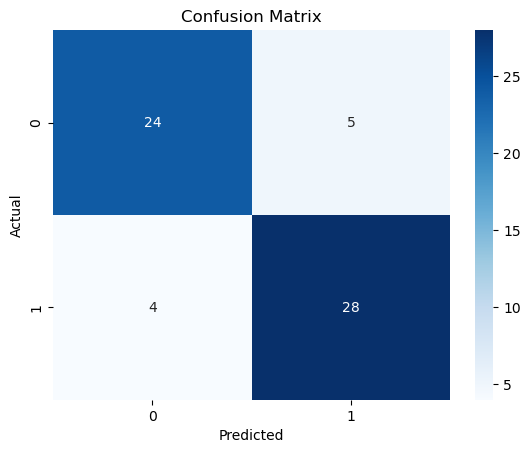

In [849]:
# COFUSION MATRIX
rfc = confusion_matrix(y_test, rfc_pred)
# HEATMAP
sns.heatmap(rfc, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [850]:
# 8 MACHINE LEARNING ALGORITHM APPLICATION
classifiers = [[XGBClassifier(), 'XGB Classifier'],
               [RandomForestClassifier(), 'Random Forest'],
               [KNeighborsClassifier(), 'K-Nearest Neighbors'],
               [SGDClassifier(), 'SGD Classifier'],
               [SVC(), 'svc'],
               [GaussianNB(), 'Naive Bayes'],
               [DecisionTreeClassifier(random_state=42), 'Decision Tree'],
               [LogisticRegression(), 'Logistic Regression']
              ]

In [851]:
acc_list = {}
precision_list = {}
recall_list = {}
roc_list = {}

for classifier in classifiers:
    model = classifier[0]
    model.fit(X_train, y_train)
    model_name = classifier[1]

    pred = model.predict(X_test)

    a_score = accuracy_score(y_test, pred)
    p_score = precision_score(y_test, pred)
    r_score = recall_score(y_test, pred)
    roc_score = roc_auc_score(y_test, pred)

    acc_list[model_name] = [str(round(a_score * 100, 2)) + '%']
    precision_list[model_name] = [str(round(p_score * 100, 2)) + '%']
    recall_list[model_name] = [str(round(r_score * 100, 2)) + '%']
    roc_list[model_name] = [str(round(roc_score * 100, 2)) + '%']

    if model_name == classifiers[-1][1]:
        print('')

In [852]:
acc_list

{'XGB Classifier': ['81.97%'],
 'Random Forest': ['86.89%'],
 'K-Nearest Neighbors': ['75.41%'],
 'SGD Classifier': ['80.33%'],
 'svc': ['65.57%'],
 'Naive Bayes': ['86.89%'],
 'Decision Tree': ['80.33%'],
 'Logistic Regression': ['85.25%']}

In [853]:
print ('Accuracy Score')
s1 = pd.DataFrame(acc_list)
s1.head()

Accuracy Score


,XGB Classifier,Random Forest,K-Nearest Neighbors,SGD Classifier,svc,Naive Bayes,Decision Tree,Logistic Regression
0,81.97%,86.89%,75.41%,80.33%,65.57%,86.89%,80.33%,85.25%


In [854]:
print ('Precision')
s2 = pd.DataFrame(precision_list)
s2.head()

Precision


,XGB Classifier,Random Forest,K-Nearest Neighbors,SGD Classifier,svc,Naive Bayes,Decision Tree,Logistic Regression
0,86.21%,85.29%,79.31%,88.46%,65.71%,90.0%,91.67%,87.1%


In [855]:
print ('Recall')
s3 = pd.DataFrame(recall_list)
s3.head()

Recall


,XGB Classifier,Random Forest,K-Nearest Neighbors,SGD Classifier,svc,Naive Bayes,Decision Tree,Logistic Regression
0,78.12%,90.62%,71.88%,71.88%,71.88%,84.38%,68.75%,84.38%


In [856]:
print ('ROC_Score')
s4 = pd.DataFrame(roc_list)
s4.head()

ROC_Score


,XGB Classifier,Random Forest,K-Nearest Neighbors,SGD Classifier,svc,Naive Bayes,Decision Tree,Logistic Regression
0,82.17%,86.69%,75.59%,80.77%,65.25%,87.02%,80.93%,85.29%
